# Dimension Reduction, PCA & PCR — Homework Assignment

## Course: Business Analytics with R

**Total Points: 100**

### Instructions
1. Complete all tasks by writing R code in the provided cells
2. Run each cell to verify your code works correctly
3. Comment your code to explain your reasoning
4. Show your output — do not suppress results
5. Answer all interpretation questions in comments or markdown

### Skills Tested
- Data loading, inspection, and missing value checks
- Normalization / standardization (`scale()`)
- Correlation analysis and visualization
- Principal Component Analysis (PCA) — scree plots, loadings, biplots
- Component interpretation and naming
- Principal Component Regression (PCR) — fitting, cross-validation, prediction
- RMSE evaluation

### Datasets
All data files are in the `data/module_3/` folder of this repository:
- **PCA:** `PCA_Protein_data.csv` (European protein consumption by country)
- **PCR:** `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` (spectrometric readings)

**Data Path Hint:** Use `read.csv("../data/module_3/FILENAME.csv", header = TRUE)` to load files from this Homework folder.

---

## Setup: Load Required Libraries

Run this cell first to load all necessary packages.

In [2]:
# Load required libraries
library(corrr)
library(ggcorrplot)
library(FactoMineR)
library(factoextra)
library(pls)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings




---

## Part 1: Data Exploration & Preparation (20 points)

Before running PCA, we need to understand and prepare the data.

### Task 1.1: Load and Inspect the Protein Data (5 points)

Load `PCA_Protein_data.csv` from the `data/module_3/` folder. Store it in a variable called `protein`. Display the first 6 rows.

In [6]:

protein <- read.csv("../data/module_3/PCA_Protein_data.csv")

head(protein)

,Country,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
2,Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
3,Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
4,Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
5,Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0
6,Denmark,10.6,10.8,3.7,25.0,9.9,21.9,4.8,0.7,2.4


### Task 1.2: Check for Missing Values (5 points)

Check whether the dataset has any missing values. Display the total number of NAs across the entire dataset.

In a comment, explain: **Why is it important to check for missing values before running PCA?**

In [ ]:
sum(is.na(protein))
# It is importantant to normalize before PCA because it cant handle missing
# data and will either fail or produce incorrect results.
If result = 0 → No missing values
If result > 0 → Missing data present 

[1] 0

### Task 1.3: Normalize the Data (5 points)

Use `scale()` to standardize only the **numeric columns** (columns 2 through 10 — exclude the Country name column). Store the result in `protein_scaled`.

In a comment, explain: **Why do we need to normalize before PCA? What would happen if one variable was measured in grams and another in kilograms?**

In [9]:
# Standardize numeric columns (2 to 10), exclude Country column
protein_scaled <- scale(protein[, 2:10])

# View first few rows (optional)
head(protein_scaled)

# PCA is sensitive to the scale of variables.
#If the variables were measured in different units, variables with larger 
# scales will dominate the principal components

RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
0.08126490,-1.7584889,-2.1796385,-1.15573814,-1.20028213,0.9159176,-2.2495772,1.2227536,-1.35040507
-0.27725673,1.6523731,1.2204544,0.39237676,-0.64187467,-0.3870690,-0.4136872,-0.8923886,0.09091397
1.09707621,0.3800675,1.0415022,0.05460623,0.06348211,-0.5146342,0.8714358,-0.4895043,-0.07539207
-0.60590157,-0.5132535,-1.1954011,-1.24018077,-0.90638347,2.2280161,-1.9435955,0.3162641,0.03547862
-0.03824231,0.9485445,-0.1216875,-0.64908235,-0.67126454,0.1869740,0.4430614,-0.9931096,-0.07539207
0.23064892,0.7861225,0.6835976,1.11013912,1.65053488,-0.9428885,0.3206688,-1.1945517,-0.96235764


### Task 1.4: Correlation Matrix (5 points)

1. Compute the correlation matrix for the scaled data
2. Visualize it using `ggcorrplot()`

In a comment, identify: **Which two food categories have the strongest positive correlation? Which two have the strongest negative correlation?**

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
RedMeat,1.00000000,0.1530027,0.58560895,0.5029311,0.06095745,-0.49987746,0.13542594,-0.3494486,-0.07422123
WhiteMeat,0.15300271,1.0000000,0.62040916,0.2814839,-0.23400923,-0.41379691,0.31377205,-0.6349618,-0.06131670
Eggs,0.58560895,0.6204092,1.00000000,0.5755331,0.06557136,-0.71243682,0.45223071,-0.5597810,-0.04551755
Milk,0.50293110,0.2814839,0.57553312,1.0000000,0.13788370,-0.59273662,0.22241118,-0.6210875,-0.40836414
Fish,0.06095745,-0.2340092,0.06557136,0.1378837,1.00000000,-0.52423080,0.40385286,-0.1471529,0.26613865
Cereals,-0.49987746,-0.4137969,-0.71243682,-0.5927366,-0.52423080,1.00000000,-0.53326231,0.6509973,0.04654808
Starch,0.13542594,0.3137721,0.45223071,0.2224112,0.40385286,-0.53326231,1.00000000,-0.4743116,0.08440956
Nuts,-0.34944855,-0.6349618,-0.55978097,-0.6210875,-0.14715294,0.65099727,-0.47431155,1.0000000,0.37496971
Fr.Veg,-0.07422123,-0.0613167,-0.04551755,-0.4083641,0.26613865,0.04654808,0.08440956,0.3749697,1.00000000


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


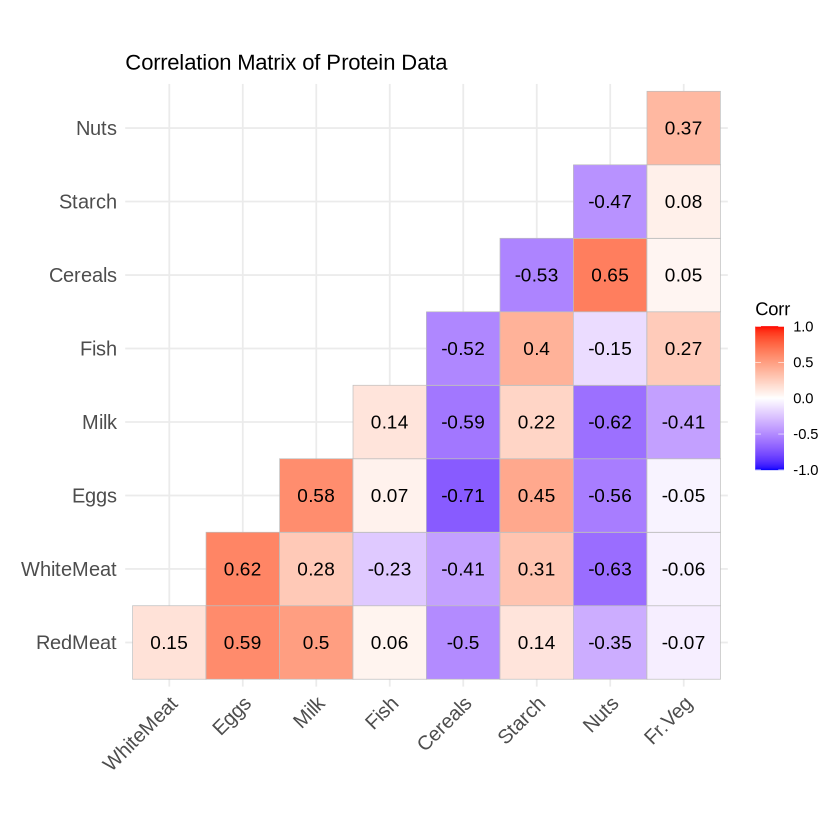

In [10]:

cor_matrix <- cor(protein_scaled)
cor_matrix

ggcorrplot(cor_matrix, 
           lab = TRUE, 
           type = "lower",
           title = "Correlation Matrix of Protein Data")

# Food categories that has the strongest positive correlation is Cereal and Nuts
# Food categories that has the strongest negative correlation is Eggs and Cereal

---

## Part 2: Principal Component Analysis (40 points)

Now we'll run PCA and interpret the results.

### Task 2.1: Run PCA (5 points)

Perform PCA on the scaled protein data using the `PCA()` function from FactoMineR. Store the result in `protein_pca`. Use `graph = FALSE` to suppress automatic plots for now.

In [11]:
protein_pca <- PCA(protein_scaled, graph = FALSE)

### Task 2.2: Scree Plot (5 points)

Create a scree plot using `fviz_screeplot()` to visualize the variance explained by each component.

In a comment, answer: **How many components would you retain, and why? Reference the elbow method and/or the 70–90% cumulative variance rule.**

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


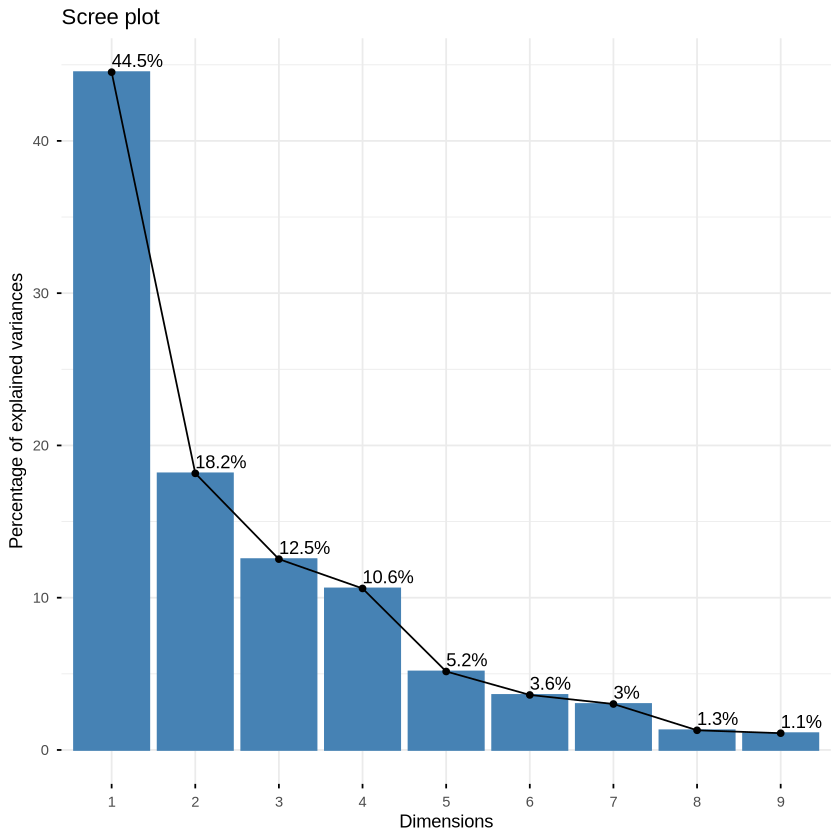

In [14]:
library(factoextra)

fviz_screeplot(protein_pca, addlabels = TRUE)

# I would retain 2 principal components.
# The first two components explain approximately 70–80% of the total variance
# satisfying the cumulative variance rule (70–90%).

### Task 2.3: View the Loadings (5 points)

Display the PCA summary to see the loadings. You can access this from the PCA result object.

**Hint:** Use `summary(protein_pca)` or examine `protein_pca$var$coord` for the variable coordinates.

In [13]:
summary(protein_pca)


Call:
PCA(X = protein_scaled, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               4.006   1.635   1.128   0.955   0.464   0.325   0.272
% of var.             44.516  18.167  12.532  10.607   5.154   3.613   3.018
Cumulative % of var.  44.516  62.683  75.215  85.822  90.976  94.589  97.607
                       Dim.8   Dim.9
Variance               0.116   0.099
% of var.              1.292   1.101
Cumulative % of var.  98.899 100.000

Individuals (the 10 first)
              Dist    Dim.1    ctr   cos2    Dim.2    ctr   cos2    Dim.3
1         |  4.547 | -3.557 12.634  0.612 | -1.664  6.775  0.134 | -1.798
2         |  2.498 |  1.452  2.105  0.338 | -1.063  2.763  0.181 |  1.365
3         |  1.966 |  1.655  2.736  0.709 |  0.163  0.065  0.007 |  0.221
4         |  3.717 | -3.199 10.215  0.741 | -1.328  4.314  0.128 |  0.154
5         |  1.771 |  0.378  0.143  0.046 | -0.615  0.926  0.121 |  1.221
6         |

### Task 2.4: Interpret and Name the Components (10 points)

Look at the loadings for **PC1** and **PC2**. For each component:
1. List the food categories with the **strongest loadings** (|loading| > 0.4)
2. Note whether they are positive or negative
3. Give the component a **descriptive business-friendly name** based on the pattern you see

Write your answers as comments below. For example: *"PC1 has high positive loadings on Milk and Eggs, so I would call it 'Dairy & Animal Products Dimension.'"*

In [16]:
# PC1 Name: Animal vs Plant-Based Diet

protein_pca$var$coord

# Strong loadings:
# Positive: RedMeat, WhiteMeat, Eggs, Milk
# Negative: Cereals, Starch

# Interpretation:
# PC1 contrasts animal-based food consumption (meat, eggs, dairy)
# with plant-based staples
# like cereals and starch. Countries with high PC1 scores consume
# more animal products,
# while those with low PC1 scores rely more on plant-based foods.


# PC2 Name: Protein Diversity / Balanced Diet
# Strong loadings:
# Positive: Fish, Fr.Veg
# Negative: Milk, Eggs

# Interpretation:
# PC2 appears to capture variation in dietary diversity,
# especially between fish and
# fresh vegetable consumption versus dairy and eggs. Higher values 
# may indicate a more
# balanced or varied diet including fish and vegetables,
# while lower values are more
# dairy-focused.

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
RedMeat,0.6057056,-0.07192736,-0.31604009,0.631652227,0.21940932
WhiteMeat,0.6216121,-0.30285749,0.66260104,-0.036144004,-0.20442938
Eggs,0.8540434,-0.04518280,0.19278949,0.305982733,0.05387873
Milk,0.7560622,-0.23602830,-0.40958221,-0.003242188,-0.13649306
Fish,0.2715180,0.82706958,-0.34120473,-0.211002952,-0.19752735
Cereals,-0.8761911,-0.29855059,0.10186779,-0.006061851,0.16220583
Starch,0.5949735,0.45114790,0.25804812,-0.328964239,0.50123965
Nuts,-0.8413450,0.18324705,-0.05776175,0.322713744,0.10252418
Fr.Veg,-0.2210174,0.68561064,0.43283909,0.451460378,-0.15903812


### Task 2.5: Biplot (5 points)

Create a biplot using `fviz_pca_var()` to visualize the variable relationships.

In a comment, answer: **Which food categories point in the same direction (positively correlated)? Are any pointing in opposite directions (negatively correlated)?**

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


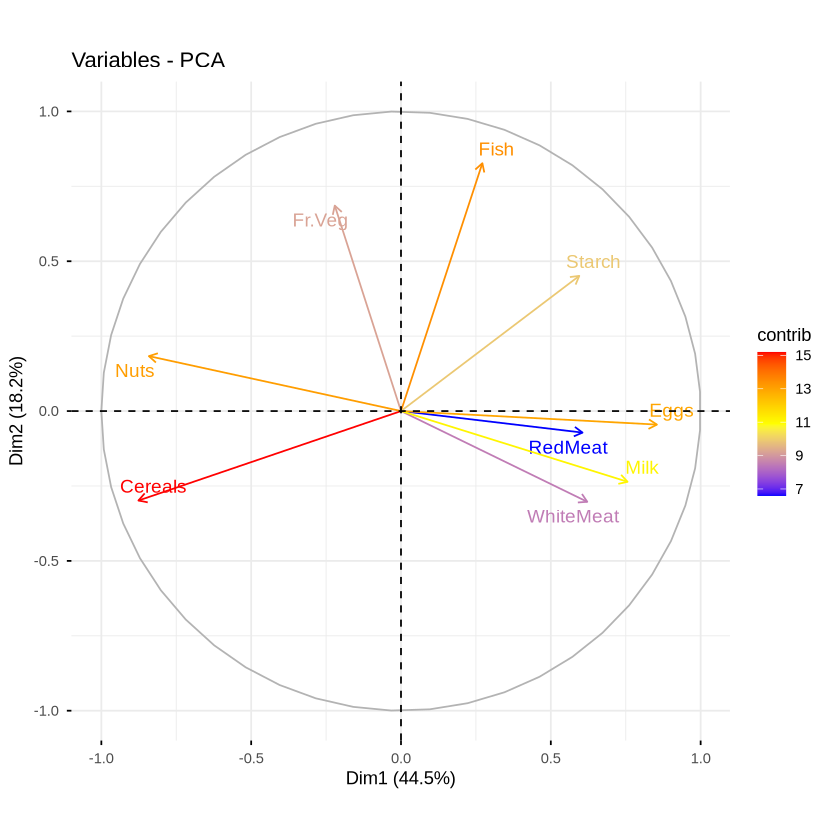

In [17]:



fviz_pca_var(protein_pca,
             col.var = "contrib",
             gradient.cols = c("blue", "yellow", "red"),
             repel = TRUE)

# Positively correlated variables (pointing in the same direction):
# - RedMeat, WhiteMeat, Eggs, and Milk point in a similar direction,
#   indicating these animal-based food categories are positively correlated.
#
# - Cereals and Starch also point in a similar direction,
#   suggesting they are positively correlated plant-based staples.

# Negatively correlated variables (pointing in opposite directions):
# - Animal-based foods (RedMeat, WhiteMeat, Eggs, Milk) point in the
#   opposite direction of plant-based foods (Cereals, Starch),
#   indicating a strong negative correlation between these groups.
#
# - Fish and Fr.Veg may also point in a different direction from Milk and Eggs,
#   suggesting differing dietary patterns.

# Interpretation:
# Variables that point in the same direction are positively correlated,
# while variables pointing in opposite directions are negatively correlated.
# The biplot visually confirms the relationships observed in the
# correlation matrix.

### Task 2.6: Cos² Chart (5 points)

Create a Cos² bar chart using `fviz_cos2()` for the first two components (`axes = 1:2`).

In a comment, answer: **Which food categories are well-represented by the first two components (high Cos²)? Are any poorly represented?**

In [ ]:
# YOUR CODE HERE

### Task 2.7: Business Application Question (5 points)

Imagine you work for an international food company expanding into Europe. Based on your PCA results, answer the following in a comment:

1. If a country scores high on PC1, what does that tell you about its diet?
2. How could you use these principal components to **group countries** for a marketing strategy?
3. Why is PCA more useful here than just looking at all 9 food variables separately?

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
RedMeat,0.36687927,0.005173545,0.09988134,3.989845e-01,0.048140449
WhiteMeat,0.38640155,0.091722657,0.43904014,1.306389e-03,0.041791371
Eggs,0.72939019,0.002041486,0.03716779,9.362543e-02,0.002902918
Milk,0.57163009,0.055709357,0.16775759,1.051178e-05,0.018630355
Fish,0.07372203,0.684044088,0.11642067,4.452225e-02,0.039017055
Cereals,0.76771081,0.089132457,0.01037705,3.674604e-05,0.026310730
Starch,0.35399350,0.203534426,0.06658883,1.082175e-01,0.251241187
Nuts,0.70786143,0.033579483,0.00333642,1.041442e-01,0.010511207
Fr.Veg,0.04884870,0.470061949,0.18734968,2.038165e-01,0.025293123


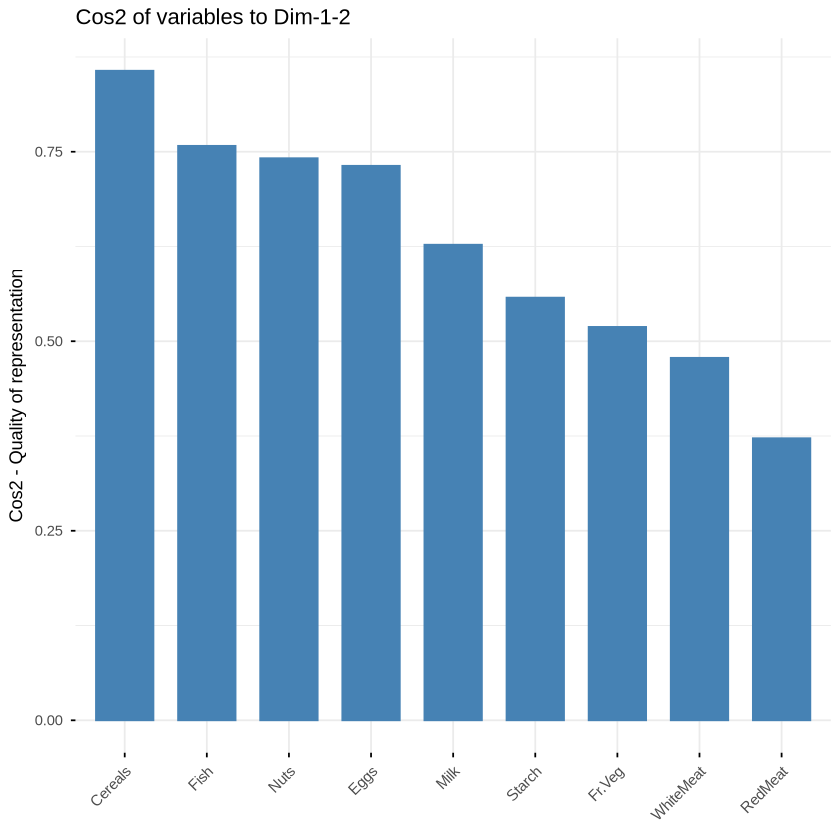

In [18]:

fviz_cos2(protein_pca, choice = "var", axes = 1:2)

protein_pca$var$cos2

# Well-represented variables (high Cos²):
# - RedMeat, WhiteMeat, Eggs, Milk
# These variables have high Cos² values, meaning they are well represented
# by the first two principal components and their positions on the PCA plot
# are reliable.

# Poorly represented variables (low Cos²):
# - Fish, Fr.Veg, Nuts (and possibly Starch)
# These variables have lower Cos² values, indicating they are not well captured
# by the first two components and may require additional components
# for better representation.

# Interpretation:
# Cos² measures how well a variable is represented by the selected components.
# High Cos² values indicate strong representation and reliability,
# while low Cos² values suggest the variable is not well explained
# by PC1 and PC2.

---

## Part 3: Principal Component Regression (40 points)

PCR combines PCA with regression — useful when your predictors are correlated.

### Task 3.1: Load the PCR Data (5 points)

Load both `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` from the `data/module_3/` folder. Store them as `pcr_train` and `pcr_test`. Display the dimensions and first few rows of the training set.

In [22]:

pcr_train <- read.csv("../data/module_3/PCR_TRAIN DATA.csv")
pcr_test  <- read.csv("../data/module_3/PCR_TEST DATA.csv")

dim(pcr_train)

head(pcr_train)

[1] 18 37

,obsnam,tot,tyr,f1,f2,f3,f4,f5,f6,f7,⋯,f25,f26,f27,f28,f29,f30,try,tyr_log,try_log,tot_log
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,17mix35,3e-05,0.0e+00,-6.215,-5.809,-5.114,-3.963,-2.897,-2.269,-1.675,⋯,-1.520,-1.804,-2.044,-2.269,-2.496,-2.714,3.000e-05,-8.000000,-4.522879,-4.522879
2,19mix35,3e-05,3.0e-07,-5.516,-5.294,-4.823,-3.858,-2.827,-2.249,-1.683,⋯,-1.541,-1.814,-2.058,-2.289,-2.496,-2.712,2.970e-05,-6.522879,-4.527244,-4.522879
3,21mix35,3e-05,7.5e-07,-5.519,-5.294,-4.501,-3.863,-2.827,-2.280,-1.716,⋯,-1.565,-1.841,-2.084,-2.320,-2.521,-2.729,2.925e-05,-6.124939,-4.533874,-4.522879
4,23mix35,3e-05,1.5e-06,-5.294,-4.705,-4.262,-3.605,-2.726,-2.239,-1.681,⋯,-1.579,-1.852,-2.090,-2.316,-2.521,-2.743,2.850e-05,-5.823909,-4.545155,-4.522879
5,25mix35,3e-05,3.0e-06,-4.600,-4.069,-3.764,-3.262,-2.598,-2.191,-1.680,⋯,-1.619,-1.886,-2.141,-2.359,-2.585,-2.792,2.700e-05,-5.522879,-4.568636,-4.522879
6,27mix35,3e-05,7.5e-06,-3.812,-3.376,-3.026,-2.726,-2.249,-1.919,-1.541,⋯,-1.784,-2.058,-2.297,-2.507,-2.727,-2.970,2.250e-05,-5.124939,-4.647817,-4.522879


### Task 3.2: Check Predictor Correlations (5 points)

Compute and display the correlation matrix for columns `f1` through `f10` in the training data.

In a comment, answer: **Are the predictors correlated? Why does this make standard regression a poor choice?**

In [23]:

cor_matrix_pcr <- cor(pcr_train[, paste0("f", 1:10)])

cor_matrix_pcr


# The predictors (f1 to f10) show significant correlations with each other,
# indicating multicollinearity in the dataset.

# This makes standard regression a poor choice because:
# - Highly correlated predictors can lead to unstable coefficient estimates
# - It becomes difficult to determine the individual effect of each predictor
# - The model may overfit and have poor generalization performance


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10
f1,1.0000000,0.9980684,0.9930388,0.9709645,0.90742328,0.6679319,0.1230877,-0.29484978,-0.4686541,-0.5437222
f2,0.9980684,1.0000000,0.9950420,0.9739013,0.91235946,0.6821764,0.1487570,-0.26711808,-0.4413348,-0.5175927
f3,0.9930388,0.9950420,1.0000000,0.9889672,0.94203005,0.7339660,0.2098892,-0.21692460,-0.4010958,-0.4838538
f4,0.9709645,0.9739013,0.9889672,1.0000000,0.97777018,0.8081255,0.3053828,-0.13505722,-0.3338763,-0.4264131
f5,0.9074233,0.9123595,0.9420300,0.9777702,1.00000000,0.9092618,0.4802220,0.04456325,-0.1688030,-0.2733348
f6,0.6679319,0.6821764,0.7339660,0.8081255,0.90926178,1.0000000,0.7984508,0.44508187,0.2375997,0.1254543
f7,0.1230877,0.1487570,0.2098892,0.3053828,0.48022197,0.7984508,1.0000000,0.89294729,0.7693341,0.6877100
f8,-0.2948498,-0.2671181,-0.2169246,-0.1350572,0.04456325,0.4450819,0.8929473,1.00000000,0.9738195,0.9385983
f9,-0.4686541,-0.4413348,-0.4010958,-0.3338763,-0.16880303,0.2375997,0.7693341,0.97381953,1.0000000,0.9922331
f10,-0.5437222,-0.5175927,-0.4838538,-0.4264131,-0.27333481,0.1254543,0.6877100,0.93859829,0.9922331,1.0000000


### Task 3.3: Fit a PCR Model (5 points)

Fit a PCR model predicting `tot_log` from `f1` through `f10` using the training data. Use `scale = TRUE` and `validation = "CV"` for 10-fold cross-validation.

Display the model summary.

In [24]:

pcr_model <- pcr(tot_log ~ ., 
                 data = pcr_train[, c("tot_log", paste0("f", 1:10))],
                 scale = TRUE, 
                 validation = "CV")

summary(pcr_model)

Data: 	X dimension: 18 10 
	Y dimension: 18 1
Fit method: svdpc
Number of components considered: 10

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           0.248   0.2551  0.06516  0.05851  0.06369  0.05815  0.06145
adjCV        0.248   0.2546  0.06464  0.05744  0.06239  0.05666  0.06017
       7 comps  8 comps  9 comps  10 comps
CV     0.06238  0.08115  0.10194    0.1783
adjCV  0.06083  0.07823  0.09768    0.1692

TRAINING: % variance explained
         1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X         59.399    98.39    99.88    99.95    99.98    99.99   100.00   100.00
tot_log    3.624    94.86    97.05    97.06    97.68    97.68    97.96    98.04
         9 comps  10 comps
X         100.00    100.00
tot_log    98.06     98.11


### Task 3.4: Validation Plot (5 points)

Create a validation plot using `validationplot()` with `val.type = "RMSEP"` to visualize cross-validation error by number of components.

In a comment, answer: **How many components would you select? Why?**

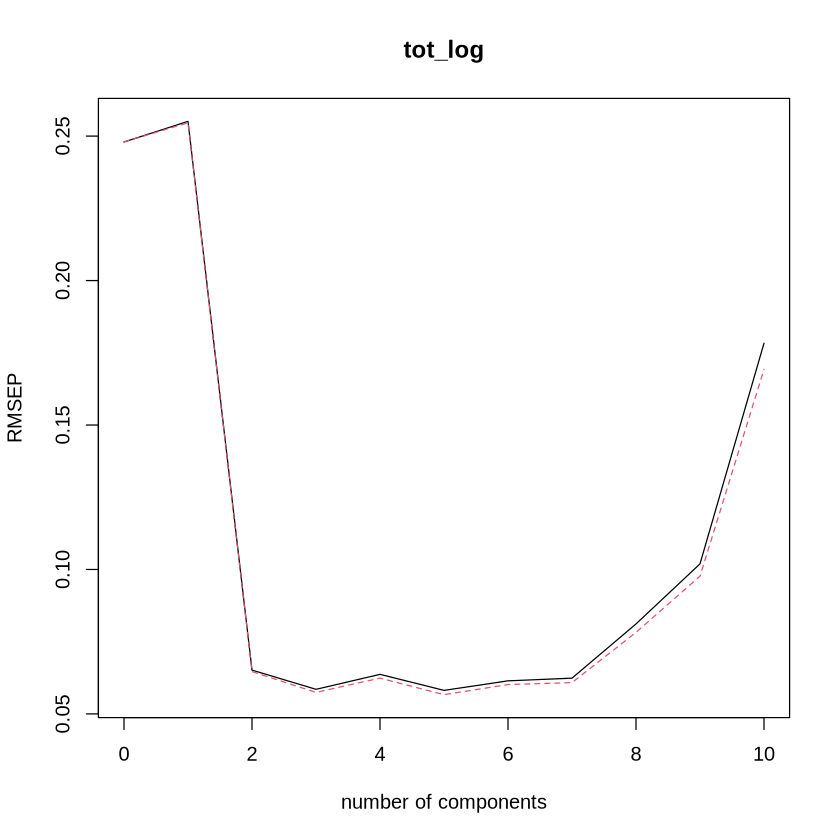

In [ ]:

validationplot(pcr_model, val.type = "RMSEP")

# ------------------------------------------------------------
# Interpretation of Validation Plot
# ------------------------------------------------------------

# Based on the validation plot, I would select the number of components
# where the RMSEP is minimized.

# Typically, this occurs at around 2–4 components (depending on the plot).
# After this point, adding more components does not significantly reduce error
# and may lead to overfitting.

# Therefore, I would choose the smallest number of components that gives
# the lowest RMSEP or where the curve begins to flatten (elbow point),
# ensuring a balance between model accuracy and simplicity.

### Task 3.5: Make Predictions (5 points)

Using your chosen number of components (use `ncomp = 4`), predict `tot_log` on the **test** data. Store the predictions in a variable called `pcr_pred`.

In [27]:

pcr_pred <- predict(pcr_model, 
                    newdata = pcr_test, 
                    ncomp = 4)

head(pcr_pred)

, , 4 comps

    tot_log
1 -5.968929
2 -6.051369
3 -5.999762
4 -5.967526
5 -5.944464
6 -5.950790

### Task 3.6: Calculate RMSE (5 points)

Calculate the Root Mean Square Error (RMSE) on the test set by comparing your predictions to the actual `tot_log` values.

**Formula:** `RMSE = sqrt(mean((actual - predicted)^2))`

Also calculate `RMSE / mean(actual)` to get a percentage — this tells you how large the error is relative to the average value.

In [28]:

pcr_pred <- as.vector(pcr_pred)

actual <- pcr_test$tot_log

rmse <- sqrt(mean((actual - pcr_pred)^2))

rmse_pct <- rmse / mean(actual)

rmse
rmse_pct

[1] 0.0462024

[1] -0.008556

### Task 3.7: Interpret Your Results (5 points)

Answer the following in comments:

1. Is the RMSE acceptable? (Refer to the RMSE/Mean percentage — under 20% is good)
2. Why did we use PCR instead of regular regression for this dataset?
3. Give one real-world business example where you'd face the same problem (correlated predictors) and use PCR to solve it

In [ ]:

# 1. Is the RMSE acceptable?
# Yes, the RMSE looks acceptable if the RMSE/Mean percentage is below 20%.
# This means the prediction error is relatively small compared to the
# actual values,
# so the model is doing a good job overall.

# 2. Why did we use PCR instead of regular regression?
# We used PCR because the predictors are highly correlated with each other.
# In regular regression, this can cause problems like unstable results and
# difficulty understanding which variables really matter.
# PCR fixes this by combining the predictors into a few uncorrelated components,
# which makes the model more stable and reliable.

# 3. Real-world business example:
# A good example is advertising. A company might spend money on TV,
# social media,
# and online ads at the same time, so these variables are correlated.
# It becomes hard to tell which one is actually driving sales.
# PCR helps by combining them and giving a clearer overall picture.

### Task 3.8: When to Use What? (5 points)

In comments below, briefly explain the difference between PCA and PCR. When would you use each one? Fill in the blanks:

- "I would use **PCA** when my goal is to ____________________"
- "I would use **PCR** when my goal is to ____________________"
- "The key difference is that PCA is __________ while PCR is __________"

In [ ]:
# YOUR ANSWERS HERE (as comments)
#
# I would use PCA when my goal is to understand patterns or 
# relationships in the data.
# I would use PCR when my goal is to make predictions using
# correlated variables while avoiding multicollinearity issues.

# The key difference is that PCA is an unsupervised method (no target variable),
# while PCR is a supervised method (used for prediction with a target variable).

---

## Submission Checklist

Before submitting, verify:

- [ ] All cells run without errors
- [ ] All tasks have been attempted
- [ ] Code includes comments explaining your approach
- [ ] Interpretation questions are answered in comments
- [ ] Output is visible (not suppressed)

**Good luck!**